In [10]:
import pandas as pd

df = pd.read_csv("Loan.csv")

print(df.head())
print(df.info())

         id  member_id  loan_amnt  funded_amnt  funded_amnt_inv        term  \
0  68407277        NaN     3600.0       3600.0           3600.0   36 months   
1  68355089        NaN    24700.0      24700.0          24700.0   36 months   
2  68341763        NaN    20000.0      20000.0          20000.0   60 months   
3  66310712        NaN    35000.0      35000.0          35000.0   60 months   
4  68476807        NaN    10400.0      10400.0          10400.0   60 months   

   int_rate  installment grade sub_grade  ... hardship_payoff_balance_amount  \
0     13.99       123.03     C        C4  ...                            NaN   
1     11.99       820.28     C        C1  ...                            NaN   
2     10.78       432.66     B        B4  ...                            NaN   
3     14.85       829.90     C        C5  ...                            NaN   
4     22.45       289.91     F        F1  ...                            NaN   

  hardship_last_payment_amount disbursement_

/tmp/ipykernel_1248/2114137992.py:3: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("Loan.csv")


In [11]:
df = df[
[
'loan_amnt',
'term',
'int_rate',
'annual_inc',
'emp_length',
'home_ownership',
'purpose',
'grade',
'loan_status'
]
]

In [12]:
print(df.isnull().sum())

loan_amnt           0
term                0
int_rate            0
annual_inc          0
emp_length        536
home_ownership      0
purpose             0
grade               0
loan_status         0
dtype: int64


In [13]:
df.dropna(inplace=True)

In [14]:
df['int_rate'] = df['int_rate'].astype(str).str.replace('%','').astype(float)
df['term'] = df['term'].astype(str).str.extract('(\\d+)').astype(int)

In [15]:
print(df.describe())

          loan_amnt         term     int_rate    annual_inc
count   9272.000000  9272.000000  9272.000000  9.272000e+03
mean   15306.808132    43.250216    12.301638  8.065364e+04
std     8739.131883    11.020556     4.311565  6.581338e+04
min     1000.000000    36.000000     5.320000  3.800000e+03
25%     8400.000000    36.000000     9.170000  5.000000e+04
50%    14150.000000    36.000000    11.990000  7.000000e+04
75%    20700.000000    60.000000    14.850000  9.800000e+04
max    35000.000000    60.000000    28.990000  3.964280e+06


In [16]:
print("Average Loan Amount:",df['loan_amnt'].mean())
print("Average Income:",df['annual_inc'].mean())

Average Loan Amount: 15306.808132010354
Average Income: 80653.64439603107


In [17]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid            6670
Charged Off           1570
Current                961
Late (31-120 days)      57
In Grace Period         11
Late (16-30 days)        3
Name: count, dtype: int64


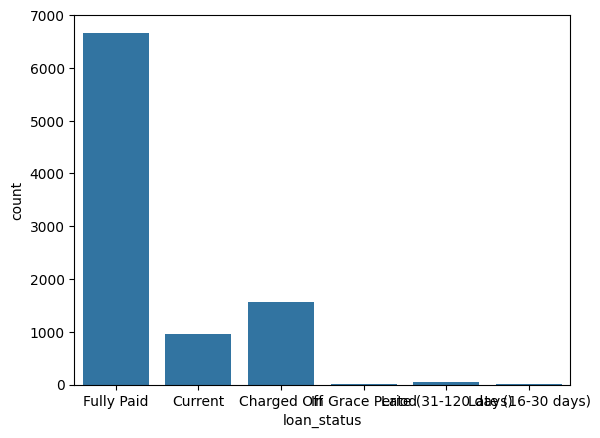

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='loan_status',data=df)
plt.show()

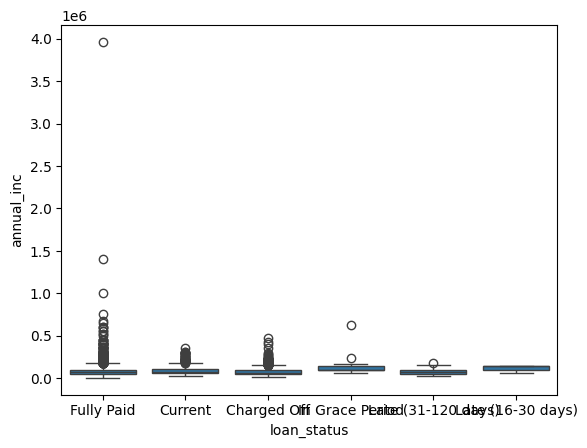

In [19]:
sns.boxplot(
x='loan_status',
y='annual_inc',
data=df
)
plt.show()

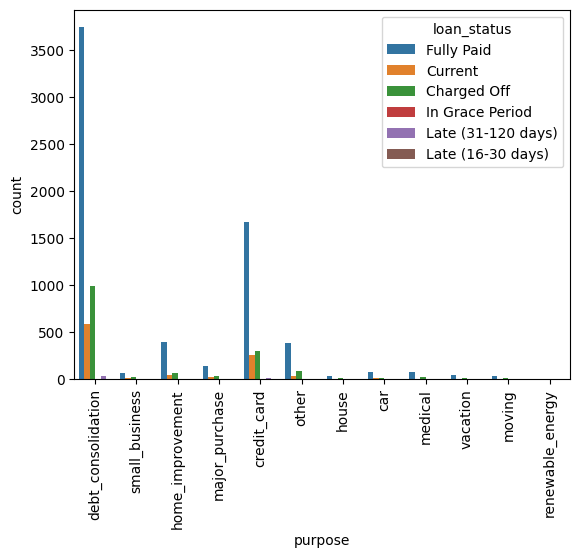

In [20]:
sns.countplot(
x='purpose',
hue='loan_status',
data=df
)
plt.xticks(rotation=90)
plt.show()

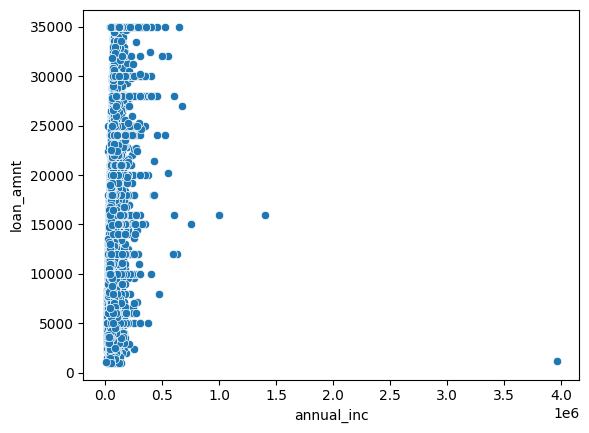

In [21]:
sns.scatterplot(
x='annual_inc',
y='loan_amnt',
data=df
)
plt.show()

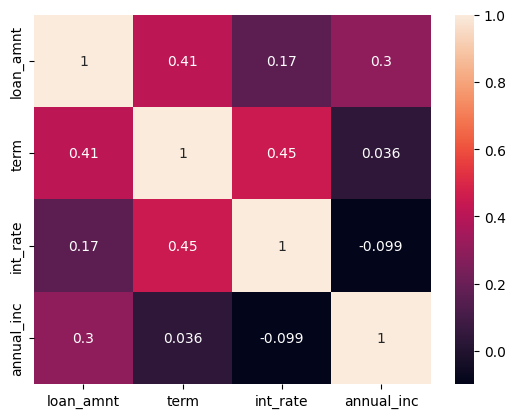

In [22]:
sns.heatmap(
df.corr(numeric_only=True),
annot=True
)
plt.show()

In [23]:
X = df[
[
'annual_inc',
'int_rate',
'term'
]
]

In [24]:
y = df['loan_amnt']

In [25]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
X,y,test_size=0.2,random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import r2_score

score = r2_score(y_test,y_pred)

print("R2 Score:",score)

R2 Score: 0.279780976379154


In [29]:
import plotly.express as px

fig = px.scatter(
df,
x='annual_inc',
y='loan_amnt',
color='loan_status'
)

fig.show()

In [30]:
fig = px.histogram(
df,
x='loan_amnt'
)

fig.show()